# Libreries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Curing promoters dataset

In [23]:
df_promoters = pd.read_csv("dataframes/12_regulonDB_parsed_and_checked_locusTag_TF.csv")

In [24]:
## Only sigma70 promoters

df_promoters = df_promoters[df_promoters['Sigma factor'] == 'sigma70']
df_promoters.reset_index(drop=True, inplace=True)

In [25]:
## Eliminate nulls in Promoter Sequence

df_promoters.dropna(subset='Promoter sequence', inplace=True)
df_promoters.reset_index(drop=True, inplace=True)

In [26]:
df_promoters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Operon ID                  1124 non-null   object 
 1   Operon name                1124 non-null   object 
 2   Operon strand              1124 non-null   object 
 3   TU ID                      1124 non-null   object 
 4   TU name                    1123 non-null   object 
 5   TU first gene              1124 non-null   object 
 6   Promoter ID                1124 non-null   object 
 7   Promoter name              1124 non-null   object 
 8   Sigma factor               1124 non-null   object 
 9   Promoter sequence          1124 non-null   object 
 10  Promoter -35 box start     1057 non-null   float64
 11  Promoter -35 box end       1057 non-null   float64
 12  Promoter -35 box sequence  1057 non-null   object 
 13  Promoter -10 box start     1098 non-null   float

In [27]:
## Eliminate duplicated Promoter Sequence

df_promoters = df_promoters[~df_promoters.duplicated(subset='Promoter sequence', keep='last')]

In [28]:
df_promoters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1068 entries, 0 to 1123
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Operon ID                  1068 non-null   object 
 1   Operon name                1068 non-null   object 
 2   Operon strand              1068 non-null   object 
 3   TU ID                      1068 non-null   object 
 4   TU name                    1067 non-null   object 
 5   TU first gene              1068 non-null   object 
 6   Promoter ID                1068 non-null   object 
 7   Promoter name              1068 non-null   object 
 8   Sigma factor               1068 non-null   object 
 9   Promoter sequence          1068 non-null   object 
 10  Promoter -35 box start     1005 non-null   float64
 11  Promoter -35 box end       1005 non-null   float64
 12  Promoter -35 box sequence  1005 non-null   object 
 13  Promoter -10 box start     1045 non-null   float64
 1

In [29]:
df_promoters[df_promoters['locus tag'].isnull()]

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Promoter -35 box sequence,Promoter -10 box start,Promoter -10 box end,Promoter -10 box sequence,Promoter confidence,spacer,promoter sequence reduced,locus tag,activator,repressor
189,RDBECOLIOPC00972,pssLA,forward,RDBECOLITUC00889,pssLA,pssL,RDBECOLIPMC01702,pssAp,sigma70,tcatgagtaaggtactggaaatgttgaccacttaatcgggactggt...,...,TTGACC,2722656.0,2722661.0,TATTAT,S,ACTTAATCGGGACTGGTGT,TTGACCACTTAATCGGGACTGGTGTTATTAT,NaN,0.0,0.0
200,RDBECOLIOPC01053,evgLAS,forward,RDBECOLITUC02540,evgLAS,evgL,RDBECOLIPMC02858,evgLp2,sigma70,atcggtacaatccctgattttattgttgacatttcatttatgccga...,...,TTCATT,2483624.0,2483629.0,TATGGT,S,TATGCCGACTATTTA,TTCATTTATGCCGACTATTTATATGGT,NaN,1.0,1.0


In [31]:
df_promoters.loc[189, 'locus tag'] = 'b4782'

In [33]:
df_promoters.loc[200, 'locus tag'] = 'b4781'

In [35]:
df_promoters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1068 entries, 0 to 1123
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Operon ID                  1068 non-null   object 
 1   Operon name                1068 non-null   object 
 2   Operon strand              1068 non-null   object 
 3   TU ID                      1068 non-null   object 
 4   TU name                    1067 non-null   object 
 5   TU first gene              1068 non-null   object 
 6   Promoter ID                1068 non-null   object 
 7   Promoter name              1068 non-null   object 
 8   Sigma factor               1068 non-null   object 
 9   Promoter sequence          1068 non-null   object 
 10  Promoter -35 box start     1005 non-null   float64
 11  Promoter -35 box end       1005 non-null   float64
 12  Promoter -35 box sequence  1005 non-null   object 
 13  Promoter -10 box start     1045 non-null   float64
 1

In [37]:
df_promoters[df_promoters['Promoter -35 box start'].isnull()]

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Promoter -35 box sequence,Promoter -10 box start,Promoter -10 box end,Promoter -10 box sequence,Promoter confidence,spacer,promoter sequence reduced,locus tag,activator,repressor
8,RDBECOLIOPC00030,acrZ,forward,RDBECOLITUC00309,acrZ,acrZ,RDBECOLIPMC02453,acrZp,sigma70,cgcaaagctgaccgcacaaaaggggagtgcttttctgtgcttagcg...,...,NaN,794739.0,794744.0,TAGAAT,S,NaN,NaN,b0762,1.0,0.0
42,RDBECOLIOPC00227,flhBAE,reverse,RDBECOLITUC03799,flhBAE,flhB,RDBECOLIPMC00019,flhBp,sigma70,cgcctgttttgccccttactcaaaccattgaacgctttgcgctctg...,...,NaN,NaN,NaN,NaN,W,NaN,NaN,b1880,1.0,0.0
48,RDBECOLIOPC00249,shoB,reverse,RDBECOLITUC01539,shoB,shoB,RDBECOLIPMC03100,shoBp,sigma70,acaccatgccacagaattcccccattgaaacgagtggtgtcgtcaa...,...,NaN,NaN,NaN,NaN,S,NaN,NaN,b4687,1.0,1.0
73,RDBECOLIOPC00373,ygfB-pepP-ubiHI,reverse,RDBECOLITUC00999,ygfB-pepP-ubiHI,ygfB,RDBECOLIPMC02461,ygfBp,sigma70,tgatgagaagagacaagcccttttctggtccaccagggcccaaagt...,...,NaN,3055480.0,3055485.0,TAGCAT,S,NaN,NaN,b2909,0.0,0.0
89,RDBECOLIOPC00470,ychH,forward,RDBECOLITUC02869,ychH,ychH,RDBECOLIPMC03113,ychHp,sigma70,agggttgtaattgtgatcacgcccgcacataacccactgggtgttg...,...,NaN,NaN,NaN,NaN,S,NaN,NaN,b1205,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,RDBECOLIOPC03536,rrsH-ileV-alaV-rrlH-rrfH,forward,RDBECOLITUC03847,rrsH-ileV-alaV-rrlH-rrfH,rrsH,RDBECOLIPMC00402,rrsHp2,sigma70,gaagagaaaaatcctgaaattcagggttgactctgaaagaggaaag...,...,NaN,223581.0,223586.0,TAATAT,S,NaN,NaN,b0201,1.0,1.0
1055,RDBECOLIOPC03541,pyrG-eno,reverse,RDBECOLITUC01776,eno,eno,RDBECOLIPMC00368,enop4,sigma70,gtaaaaaagttagagcggcaacgcgtaccctgggtacgcgttgttt...,...,NaN,2907973.0,2907980.0,CTGGAGTT,W,NaN,NaN,b2779,1.0,1.0
1056,RDBECOLIOPC03541,pyrG-eno,reverse,RDBECOLITUC01777,eno,eno,RDBECOLIPMC00369,enop7,sigma70,tctgcgcgttgcgggccgttccggggatgatcagttggtcgagatc...,...,NaN,2908159.0,2908166.0,ATCGAAGT,W,NaN,NaN,b2779,1.0,1.0
1072,RDBECOLIOPC03547,csgBAC,forward,RDBECOLITUC02112,csgA,csgA,RDBECOLIPMC02562,csgAp,sigma70,agtagcaaccgggcaaagattgaccagacaggagattataaccttg...,...,NaN,1104224.0,1104229.0,TATATT,S,NaN,NaN,b1042,1.0,1.0


In [38]:
df_promoters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1068 entries, 0 to 1123
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Operon ID                  1068 non-null   object 
 1   Operon name                1068 non-null   object 
 2   Operon strand              1068 non-null   object 
 3   TU ID                      1068 non-null   object 
 4   TU name                    1067 non-null   object 
 5   TU first gene              1068 non-null   object 
 6   Promoter ID                1068 non-null   object 
 7   Promoter name              1068 non-null   object 
 8   Sigma factor               1068 non-null   object 
 9   Promoter sequence          1068 non-null   object 
 10  Promoter -35 box start     1005 non-null   float64
 11  Promoter -35 box end       1005 non-null   float64
 12  Promoter -35 box sequence  1005 non-null   object 
 13  Promoter -10 box start     1045 non-null   float64
 1

# Gene expression dataset

In [3]:
df_geneExpression = pd.read_csv("dataframes/9_geneExpressionK12.csv")

In [41]:
locus_tag = []
for elem in df_promoters['locus tag'].values:
    if elem in df_geneExpression.columns:
        locus_tag.append(elem)

In [42]:
len(locus_tag)

958

In [43]:
df_geneExpression = df_geneExpression[locus_tag]

In [46]:
df_promoters = df_promoters[df_promoters['locus tag'].isin(locus_tag)]
df_promoters.reset_index(drop=True, inplace=True)

In [47]:
df_promoters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Operon ID                  958 non-null    object 
 1   Operon name                958 non-null    object 
 2   Operon strand              958 non-null    object 
 3   TU ID                      958 non-null    object 
 4   TU name                    957 non-null    object 
 5   TU first gene              958 non-null    object 
 6   Promoter ID                958 non-null    object 
 7   Promoter name              958 non-null    object 
 8   Sigma factor               958 non-null    object 
 9   Promoter sequence          958 non-null    object 
 10  Promoter -35 box start     901 non-null    float64
 11  Promoter -35 box end       901 non-null    float64
 12  Promoter -35 box sequence  901 non-null    object 
 13  Promoter -10 box start     936 non-null    float64

In [48]:
df_geneExpression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Columns: 958 entries, b0048 to b3728
dtypes: float64(958)
memory usage: 1.2 MB


# Save datasets

In [49]:
df_promoters.to_csv('dataframes/curated/df_promoters.csv', index=False)
df_geneExpression.to_csv('dataframes/curated/df_geneExpression.csv', index=False)

# Fitting gene expression

In [50]:
df_promoters.head(2)

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Promoter -35 box sequence,Promoter -10 box start,Promoter -10 box end,Promoter -10 box sequence,Promoter confidence,spacer,promoter sequence reduced,locus tag,activator,repressor
0,RDBECOLIOPC00006,folA,forward,RDBECOLITUC02413,folA,folA,RDBECOLIPMC03546,folAp,sigma70,ttcctcaacatcatcctcgcaccagtcgacgacggtttacgcttta...,...,GTCGAC,49787.0,49792.0,TATAGT,W,GACGGTTTACGCTTTACG,GTCGACGACGGTTTACGCTTTACGTATAGT,b0048,1.0,0.0
1,RDBECOLIOPC00013,argD,reverse,RDBECOLITUC03147,argD,argD,RDBECOLIPMC03433,argDp,sigma70,tttcctgcatcgctgatttctgattgccatttagtgattttttatg...,...,TTGCCA,3490228.0,3490233.0,TATTTT,W,TTTAGTGATTTTTTATGCA,TTGCCATTTAGTGATTTTTTATGCATATTTT,b3359,0.0,1.0


In [51]:
def search_score(promoter, box35seq, box10seq):
    df = pd.read_csv(f'phisite/dataframes/{promoter}.csv')
    score = "Unmatched"
    for i in range(len(df.index)):
        if box35seq == df['-35'][i] and box10seq == df['-10'][i]:
            score = df['Summary score'][i]
            break
    return score

In [52]:
df_promoters['phisite score'] = df_promoters.apply(lambda row: search_score(row['Promoter name'], row['Promoter -35 box sequence'], row['Promoter -10 box sequence']), axis=1)

In [56]:
def search_score_10(promoter, box10seq):
    df = pd.read_csv(f'phisite/dataframes/{promoter}.csv')
    score = "Unmatched"
    for i in range(len(df.index)):
        if box10seq == df['-10'][i]:
            score = df['Summary score'][i]
            break
    return score

In [57]:
df_promoters['phisite score -10 box'] = df_promoters.apply(lambda row: search_score_10(row['Promoter name'], row['Promoter -10 box sequence']), axis=1)

In [59]:
def search_score_35(promoter, box35seq):
    df = pd.read_csv(f'phisite/dataframes/{promoter}.csv')
    score = "Unmatched"
    for i in range(len(df.index)):
        if box35seq == df['-35'][i]:
            score = df['Summary score'][i]
            break
    return score

In [60]:
df_promoters['phisite score -35 box'] = df_promoters.apply(lambda row: search_score_35(row['Promoter name'], row['Promoter -10 box sequence']), axis=1)

In [67]:
df_geneExpression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Columns: 958 entries, b0048 to b3728
dtypes: float64(958)
memory usage: 1.2 MB


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.neighbors import KernelDensity


Picos encontrados en: [6.70320422]


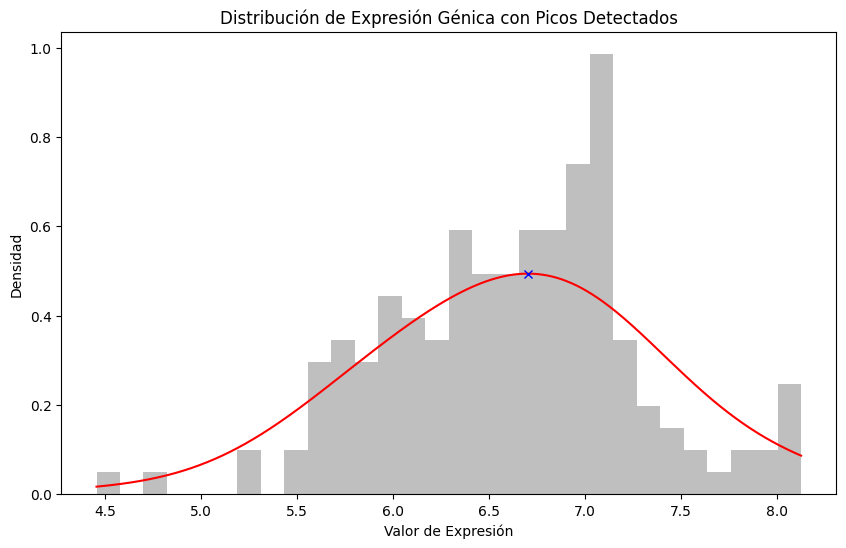

In [72]:
# Crear una función para estimar la densidad del kernel y encontrar picos
def find_peaks_in_gene_expression(gene_expression):
    # Filtrar cualquier valor no numérico
    gene_expression = gene_expression[~np.isnan(gene_expression)]
    
    # Crear un rango de valores para evaluar la densidad
    x_d = np.linspace(min(gene_expression), max(gene_expression), 1000)
    
    # Ajustar el KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(gene_expression[:, None])
    log_dens = kde.score_samples(x_d[:, None])
    density = np.exp(log_dens)
    
    # Encontrar picos en la densidad
    peaks, _ = find_peaks(density, height=0)
    
    return x_d, density, peaks

# Seleccionar una columna de ejemplo para probar la función
example_gene = df_geneExpression.iloc[:, 0].values

# Aplicar la función a la columna seleccionada
x_d, density, peaks = find_peaks_in_gene_expression(example_gene)

# Mostrar los picos encontrados
print("Picos encontrados en:", x_d[peaks])

# Graficar la distribución y los picos
plt.figure(figsize=(10, 6))
plt.hist(example_gene, bins=30, density=True, alpha=0.5, color='gray')
plt.plot(x_d, density, color='red')
plt.plot(x_d[peaks], density[peaks], "x", color='blue')
plt.title('Distribución de Expresión Génica con Picos Detectados')
plt.xlabel('Valor de Expresión')
plt.ylabel('Densidad')
plt.show()



In [75]:
# Crear una lista para guardar los resultados
results_list = []

# Iterar sobre cada columna (gen) del DataFrame
for gene in df_geneExpression.columns:
    gene_expression = df_geneExpression[gene].values
    
    # Encontrar picos en la expresión génica
    x_d, density, peaks = find_peaks_in_gene_expression(gene_expression)
    
    # Guardar los resultados en un diccionario
    result = {'locus tag': gene, 'Peak Positions': x_d[peaks]}
    results_list.append(result)

# Convertir la lista de resultados en un DataFrame
peaks_df = pd.DataFrame(results_list)

# Mostrar los resultados
print(peaks_df.head())



  locus tag                                     Peak Positions
0     b0048                                [6.703204223423423]
1     b3359             [4.438164990990991, 8.231956042042043]
2     b0572  [0.5378940910910911, 3.2932291291291294, 4.709...
3     b3338                                [3.649573944944945]
4     b4177                                [10.21994068018018]


In [76]:
peaks_df

,locus tag,Peak Positions
0,b0048,[6.703204223423423]
1,b3359,"[4.438164990990991, 8.231956042042043]"
2,b0572,"[0.5378940910910911, 3.2932291291291294, 4.709..."
3,b3338,[3.649573944944945]
4,b4177,[10.21994068018018]
...,...,...
953,b3725,[6.4380341561561565]
954,b3727,[5.41297955915916]
955,b3725,[6.4380341561561565]
956,b3724,[6.423911932432432]


In [77]:
df_promoters_geneExpression = pd.merge(df_promoters, peaks_df, on='locus tag')

In [78]:
df_promoters_geneExpression.head()

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Promoter confidence,spacer,promoter sequence reduced,locus tag,activator,repressor,phisite score,phisite score -10 box,phisite score -35 box,Peak Positions
0,RDBECOLIOPC00006,folA,forward,RDBECOLITUC02413,folA,folA,RDBECOLIPMC03546,folAp,sigma70,ttcctcaacatcatcctcgcaccagtcgacgacggtttacgcttta...,...,W,GACGGTTTACGCTTTACG,GTCGACGACGGTTTACGCTTTACGTATAGT,b0048,1.0,0.0,Unmatched,5.68,Unmatched,[6.703204223423423]
1,RDBECOLIOPC00013,argD,reverse,RDBECOLITUC03147,argD,argD,RDBECOLIPMC03433,argDp,sigma70,tttcctgcatcgctgatttctgattgccatttagtgattttttatg...,...,W,TTTAGTGATTTTTTATGCA,TTGCCATTTAGTGATTTTTTATGCATATTTT,b3359,0.0,1.0,6.63,6.63,Unmatched,"[4.438164990990991, 8.231956042042043]"
2,RDBECOLIOPC00019,cusCFBA,forward,RDBECOLITUC01807,cusCFBA,cusC,RDBECOLIPMC00440,cusCp,sigma70,tgacaattttgtcatttttctgtcaccggaaaatcagagcctggcg...,...,S,GGAAAATCAGAGCCTGGCGAG,GTCACCGGAAAATCAGAGCCTGGCGAGTAAAGT,b0572,1.0,0.0,2.95,2.95,Unmatched,"[0.5378940910910911, 3.2932291291291294, 4.709..."
3,RDBECOLIOPC00023,chiA,reverse,RDBECOLITUC01863,chiA,chiA,RDBECOLIPMC00480,chiAp,sigma70,ttttaatgccgtaatttaattcatattgaagggttctcgtaaaacg...,...,S,GGTTCTCGTAAAACGTA,TTGAAGGGTTCTCGTAAAACGTAAATAAT,b3338,0.0,1.0,5.65,5.65,Unmatched,[3.649573944944945]
4,RDBECOLIOPC00026,purA,forward,RDBECOLITUC03131,purA,purA,RDBECOLIPMC03416,purAp,sigma70,ggtcatttttgagtgcaaaaagtgctgtaactctgaaaaagcgatg...,...,S,CTCTGAAAAAGCGATGG,CTGTAACTCTGAAAAAGCGATGGTAGAAT,b4177,1.0,1.0,5.17,5.17,0.73,[10.21994068018018]


In [82]:
df_promoters_geneExpression.sort_values(['TU first gene','Promoter name']).to_csv('dataframes/curated/df_promoters_geneExpression.csv', index=False)

<Axes: xlabel='b1973', ylabel='Count'>

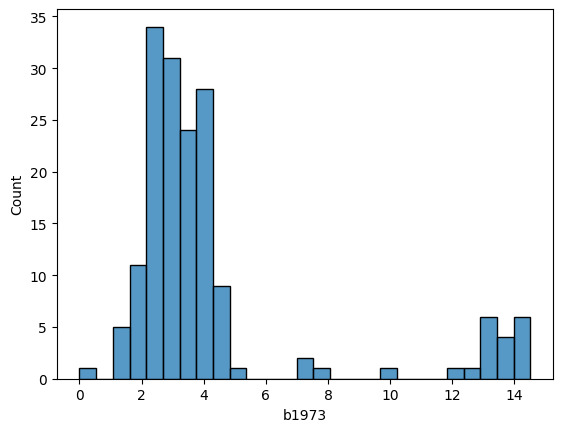

In [205]:
gene_now = 'b1973'
sns.histplot(df_geneExpression[gene_now])

# Criteria for manual curation:
1. If there is only one peak in RNAseq data, take the value.
2. If there are multiple peaks, compare with phisite score and take the nearest value. 
3. If there are multiple peaks and multiple promoters for the same gene, try to asign to each promoter a value, taking into account the date of phisite if available.
4. If there are multiple values and only one promoter, asign the more highest peak.

All values in the table correspond to RNAseq data, phisite values are only a reference. 

In [206]:
df = pd.read_csv('dataframes/curated/df_promoters_geneExpression_curated.csv')

In [208]:
df.drop_duplicates(subset='Promoter name', keep='first', inplace=True)

In [210]:
df.reset_index(drop=True, inplace=True)

In [212]:
df.to_csv('dataframes/curated/df_promoters_geneExpression_curated.csv', index=False)

# Adding categories

In [2]:
df = pd.read_csv('dataframes/curated/df_promoters_geneExpression_curated.csv')

In [3]:
df.head(2)

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Promoter -10 box sequence,Promoter confidence,spacer,promoter sequence reduced,locus tag,Peak expression,phisite score,phisite score -10 box,phisite score -35 box,Peak
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,CAAATT,S,TCTCGCTGACGGACAGG,TTGCTATCTCGCTGACGGACAGGCAAATT,b0185,8.296056,2.96,2.96,Unmatched,8.296056
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,CAGTAT,S,ATCTTCCCTGATAAGAC,TTGATTATCTTCCCTGATAAGACCAGTAT,b3255,9.684888,2.62,2.62,Unmatched,9.684888


In [84]:
scaler = MinMaxScaler(feature_range=(0,1))
df['Peak expression scaled'] = scaler.fit_transform(df[['Peak expression']])

In [86]:
df

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,phisite score,phisite score -10 box,phisite score -35 box,Peak,Peak expression scaled,K-means cluster,Manual cluster 3,Manual cluster 5,mode,Mode expression scaled
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,2.96,2.96,Unmatched,8.296056,0.553326,2,1,2,8.464876,0.600183
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,2.62,2.62,Unmatched,9.684888,0.646880,2,1,3,9.696306,0.687495
2,RDBECOLIOPC01029,accD,reverse,RDBECOLITUC03266,accD,accD,RDBECOLIPMC03733,accDp,sigma70,actccgcggttcgaccacttttttatccaaagtttcgggctgttat...,...,Unmatched,Unmatched,Unmatched,8.975477,0.599093,2,1,2,9.167668,0.650013
3,RDBECOLIOPC02303,aceBAK,forward,RDBECOLITUC03038,aceBAK,aceB,RDBECOLIPMC03316,aceBp,sigma70,tatttttaattaaaatggaaattgtttttgattttgcattttaaat...,...,4.31,4.31,Unmatched,NaN,0.671912,2,2,3,9.937939,0.704627
4,RDBECOLIOPC03350,pdhR-aceEF-lpdA,forward,RDBECOLITUC02471,aceEF,aceE,RDBECOLIPMC03551,aceEp1,sigma70,aaagcgcggcaactaaacgtagaacctgtcttattgagctttccgg...,...,Unmatched,Unmatched,Unmatched,10.219209,0.682872,2,2,3,10.233120,0.725556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,RDBECOLIOPC03208,iraD,forward,RDBECOLITUC01744,iraD,ytiC,RDBECOLIPMC00318,iraDp1,sigma70,aagcatatcttattactaattggaatttgatgttgctatattgagg...,...,5.66,5.66,Unmatched,0.060529,0.347693,1,1,1,0.000000,0.000000
951,RDBECOLIOPC01311,zinT,forward,RDBECOLITUC02623,zinT,zinT,RDBECOLIPMC02925,zinTp,sigma70,tgctctcgtttcctaagagttgttgcattttgctatatgttacaat...,...,5.03,5.03,Unmatched,NaN,0.196101,0,0,0,3.614392,0.256270
952,RDBECOLIOPC00950,zntA,forward,RDBECOLITUC02316,zntA,zntA,RDBECOLIPMC02760,zntAp,sigma70,ctcgctgtatctctgataaaacttgactctggagtcgactccagag...,...,7.26,7.26,Unmatched,4.396929,0.558137,2,1,2,4.288001,0.304031
953,RDBECOLIOPC01943,znuCB,forward,RDBECOLITUC02315,znuCB,znuC,RDBECOLIPMC02759,znuCp,sigma70,tatgtaacataatgcgaccaataatcgtaatgaatatgagaagtgt...,...,Unmatched,4.31,Unmatched,5.619474,0.373029,1,1,1,5.453687,0.386681


## K-means clusters

In [87]:
from sklearn.cluster import KMeans

# Seleccionar la métrica de variabilidad (por ejemplo, desviación estándar o coeficiente de variación)
X = df[['Peak expression scaled']]

# Aplicar K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)

# Añadir las etiquetas de los clusters al DataFrame original
df['K-means cluster'] = kmeans.labels_

In [88]:
print("0", df[df["K-means cluster"]==0]["Peak expression scaled"].min())
print("0", df[df["K-means cluster"]==0]["Peak expression scaled"].max())
print("1", df[df["K-means cluster"]==1]["Peak expression scaled"].min())
print("1", df[df["K-means cluster"]==1]["Peak expression scaled"].max())
print("2", df[df["K-means cluster"]==2]["Peak expression scaled"].min())
print("2", df[df["K-means cluster"]==2]["Peak expression scaled"].max())

0 0.28608052335235806
0 0.5082712785889164
1 0.0
1 0.28472476820953946
2 0.5132475422106563
2 1.0000000000000002


In [89]:
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: "a" if x==1 else x)
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: "b" if x==0 else x)
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: "c" if x==2 else x)

In [90]:
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: 0 if x=="a" else x)
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: 1 if x=='b' else x)
df["K-means cluster"] = df["K-means cluster"].apply(lambda x: 2 if x=='c' else x)

## Equidistant distribution

In [91]:
def clustering_3(x):
    if x >= 0 and x < 0.33333:
        return 0
    elif x >= 0.33333 and x < 0.66666:
        return 1
    else:
        return 2
    

def clustering_5(x):
    if x >= 0 and x < 0.2:
        return 0
    elif x >= 0.2 and x < 0.4:
        return 1
    elif x >= 0.4 and x < 0.6:
        return 2
    elif x >= 0.6 and x < 0.8:
        return 3
    else:
        return 4
        

In [92]:
df['Manual cluster 3 peaks'] = df['Peak expression scaled'].apply(clustering_3)

In [93]:
df['Manual cluster 5 peaks'] = df['Peak expression scaled'].apply(clustering_5)

In [37]:
df

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,promoter sequence reduced,locus tag,Peak expression,phisite score,phisite score -10 box,phisite score -35 box,Peak,Peak expression scaled,K-means cluster,Manual cluster
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,TTGCTATCTCGCTGACGGACAGGCAAATT,b0185,8.296056,2.96,2.96,Unmatched,8.296056,0.553326,2,1
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,TTGATTATCTTCCCTGATAAGACCAGTAT,b3255,9.684888,2.62,2.62,Unmatched,9.684888,0.646880,2,1
2,RDBECOLIOPC01029,accD,reverse,RDBECOLITUC03266,accD,accD,RDBECOLIPMC03733,accDp,sigma70,actccgcggttcgaccacttttttatccaaagtttcgggctgttat...,...,TTTTTATCCAAAGTTTCGGGCTGTTATGTT,b2316,8.975477,Unmatched,Unmatched,Unmatched,8.975477,0.599093,2,1
3,RDBECOLIOPC02303,aceBAK,forward,RDBECOLITUC03038,aceBAK,aceB,RDBECOLIPMC03316,aceBp,sigma70,tatttttaattaaaatggaaattgtttttgattttgcattttaaat...,...,TTGATTTTGCATTTTAAATGAGTAGTCT,b4014,10.056502,4.31,4.31,Unmatched,NaN,0.671912,2,2
4,RDBECOLIOPC03350,pdhR-aceEF-lpdA,forward,RDBECOLITUC02471,aceEF,aceE,RDBECOLIPMC03551,aceEp1,sigma70,aaagcgcggcaactaaacgtagaacctgtcttattgagctttccgg...,...,CTGTCTTATTGAGCTTTCCGGCGAGAGT,b0114,10.219209,Unmatched,Unmatched,Unmatched,10.219209,0.682872,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,RDBECOLIOPC03208,iraD,forward,RDBECOLITUC01744,iraD,ytiC,RDBECOLIPMC00318,iraDp1,sigma70,aagcatatcttattactaattggaatttgatgttgctatattgagg...,...,TTGATGTTGCTATATTGAGGTCTATATT,b4720,5.243358,5.66,5.66,Unmatched,0.060529,0.347693,1,1
951,RDBECOLIOPC01311,zinT,forward,RDBECOLITUC02623,zinT,zinT,RDBECOLIPMC02925,zinTp,sigma70,tgctctcgtttcctaagagttgttgcattttgctatatgttacaat...,...,TTGCATTTTGCTATATGTTACAATATAAC,b1973,2.992920,5.03,5.03,Unmatched,NaN,0.196101,0,0
952,RDBECOLIOPC00950,zntA,forward,RDBECOLITUC02316,zntA,zntA,RDBECOLIPMC02760,zntAp,sigma70,ctcgctgtatctctgataaaacttgactctggagtcgactccagag...,...,TTGACTCTGGAGTCGACTCCAGAGTGTATCCT,b3469,8.367476,7.26,7.26,Unmatched,4.396929,0.558137,2,1
953,RDBECOLIOPC01943,znuCB,forward,RDBECOLITUC02315,znuCB,znuC,RDBECOLIPMC02759,znuCp,sigma70,tatgtaacataatgcgaccaataatcgtaatgaatatgagaagtgt...,...,ATCGTAATGAATATGAGAAGTGTGATATTAT,b1858,5.619474,Unmatched,4.31,Unmatched,5.619474,0.373029,1,1


In [47]:
df.to_csv('dataframes/curated/df_with_clusters.csv', index=False)

# Adding mode column to the dataset

In [49]:
df_geneExpression

,index,b0002,b0003,b0004,b0005,b0006,b0007,b0008,b0009,b0010,...,b4740,b4742,b4743,b4744,b4745,b4747,b4748,b4751,b4755,b4756
0,p1k_00001,10.260570,9.920278,9.936694,7.027514,6.537183,3.043208,10.664771,5.818691,4.654060,...,3.437496,7.137727,5.265698,2.779449,1.484198,1.238282,0.000000,5.559890,2.164426,4.553727
1,p1k_00002,10.368555,10.044224,10.010638,7.237449,6.452700,2.933902,10.702458,6.109742,4.779633,...,3.260379,7.253462,4.894757,4.213492,0.000000,0.000000,0.000000,5.638994,2.634758,3.824146
2,p1k_00003,11.193605,11.045581,9.976798,6.014337,6.371349,3.316531,10.641143,6.170178,3.689891,...,3.249260,5.125056,6.477672,3.241691,0.000000,0.000000,0.000000,4.309421,5.021240,2.602982
3,p1k_00004,11.404162,11.460139,10.330368,5.854518,6.387164,3.264503,10.388623,6.110583,3.699180,...,3.445236,5.354380,6.569912,5.600386,0.000000,0.000000,0.000000,4.301115,5.655869,2.037598
4,p1k_00005,10.497016,10.374824,9.876910,6.950936,6.321764,3.091241,10.540921,5.821780,4.379725,...,2.903060,6.391959,5.558479,3.654893,1.011007,0.821856,0.000000,5.117821,2.097149,4.222657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,p1k_00816,10.808621,10.161210,9.998448,6.452578,6.472753,3.305636,10.349686,5.310376,3.882960,...,3.780517,4.114063,5.924942,4.111593,0.000000,0.811266,0.000000,4.735521,0.000000,5.760310
162,p1k_00828,9.917893,10.004788,9.746955,7.738543,5.375955,2.880520,9.595741,5.297445,4.160163,...,3.669952,5.135280,5.460251,9.114042,0.500741,2.048708,3.720950,5.723015,1.652536,4.586060
163,p1k_00829,10.049220,10.034962,9.847780,7.863723,5.608833,2.904712,9.614549,5.501834,4.018498,...,3.296394,4.836078,4.364785,9.397053,0.593973,2.029006,4.649763,5.609553,1.211601,4.349993
164,p1k_00882,10.639470,10.269375,10.192219,6.831792,6.505559,2.651878,10.615775,5.761955,4.905267,...,1.699004,3.483538,2.837202,1.589891,0.496411,1.517615,1.226617,5.107107,1.043326,4.842827


In [50]:
locus = df['locus tag']

In [58]:
df['mode'] = df_geneExpression[df['locus tag'].values].mode().mean().values

In [59]:
df

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Peak expression,phisite score,phisite score -10 box,phisite score -35 box,Peak,Peak expression scaled,K-means cluster,Manual cluster 3,Manual cluster 5,mode
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,8.296056,2.96,2.96,Unmatched,8.296056,0.553326,2,1,2,8.464876
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,9.684888,2.62,2.62,Unmatched,9.684888,0.646880,2,1,3,9.696306
2,RDBECOLIOPC01029,accD,reverse,RDBECOLITUC03266,accD,accD,RDBECOLIPMC03733,accDp,sigma70,actccgcggttcgaccacttttttatccaaagtttcgggctgttat...,...,8.975477,Unmatched,Unmatched,Unmatched,8.975477,0.599093,2,1,2,9.167668
3,RDBECOLIOPC02303,aceBAK,forward,RDBECOLITUC03038,aceBAK,aceB,RDBECOLIPMC03316,aceBp,sigma70,tatttttaattaaaatggaaattgtttttgattttgcattttaaat...,...,10.056502,4.31,4.31,Unmatched,NaN,0.671912,2,2,3,9.937939
4,RDBECOLIOPC03350,pdhR-aceEF-lpdA,forward,RDBECOLITUC02471,aceEF,aceE,RDBECOLIPMC03551,aceEp1,sigma70,aaagcgcggcaactaaacgtagaacctgtcttattgagctttccgg...,...,10.219209,Unmatched,Unmatched,Unmatched,10.219209,0.682872,2,2,3,10.233120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,RDBECOLIOPC03208,iraD,forward,RDBECOLITUC01744,iraD,ytiC,RDBECOLIPMC00318,iraDp1,sigma70,aagcatatcttattactaattggaatttgatgttgctatattgagg...,...,5.243358,5.66,5.66,Unmatched,0.060529,0.347693,1,1,1,0.000000
951,RDBECOLIOPC01311,zinT,forward,RDBECOLITUC02623,zinT,zinT,RDBECOLIPMC02925,zinTp,sigma70,tgctctcgtttcctaagagttgttgcattttgctatatgttacaat...,...,2.992920,5.03,5.03,Unmatched,NaN,0.196101,0,0,0,3.614392
952,RDBECOLIOPC00950,zntA,forward,RDBECOLITUC02316,zntA,zntA,RDBECOLIPMC02760,zntAp,sigma70,ctcgctgtatctctgataaaacttgactctggagtcgactccagag...,...,8.367476,7.26,7.26,Unmatched,4.396929,0.558137,2,1,2,4.288001
953,RDBECOLIOPC01943,znuCB,forward,RDBECOLITUC02315,znuCB,znuC,RDBECOLIPMC02759,znuCp,sigma70,tatgtaacataatgcgaccaataatcgtaatgaatatgagaagtgt...,...,5.619474,Unmatched,4.31,Unmatched,5.619474,0.373029,1,1,1,5.453687


In [81]:
scaler_mode = MinMaxScaler(feature_range=(0,1))
df['Mode expression scaled'] = scaler_mode.fit_transform(df[['mode']])

In [80]:
df

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,phisite score,phisite score -10 box,phisite score -35 box,Peak,Peak expression scaled,K-means cluster,Manual cluster 3,Manual cluster 5,mode,Mode expression scaled
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,2.96,2.96,Unmatched,8.296056,0.553326,2,1,2,8.464876,0.600183
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,2.62,2.62,Unmatched,9.684888,0.646880,2,1,3,9.696306,0.687495
2,RDBECOLIOPC01029,accD,reverse,RDBECOLITUC03266,accD,accD,RDBECOLIPMC03733,accDp,sigma70,actccgcggttcgaccacttttttatccaaagtttcgggctgttat...,...,Unmatched,Unmatched,Unmatched,8.975477,0.599093,2,1,2,9.167668,0.650013
3,RDBECOLIOPC02303,aceBAK,forward,RDBECOLITUC03038,aceBAK,aceB,RDBECOLIPMC03316,aceBp,sigma70,tatttttaattaaaatggaaattgtttttgattttgcattttaaat...,...,4.31,4.31,Unmatched,NaN,0.671912,2,2,3,9.937939,0.704627
4,RDBECOLIOPC03350,pdhR-aceEF-lpdA,forward,RDBECOLITUC02471,aceEF,aceE,RDBECOLIPMC03551,aceEp1,sigma70,aaagcgcggcaactaaacgtagaacctgtcttattgagctttccgg...,...,Unmatched,Unmatched,Unmatched,10.219209,0.682872,2,2,3,10.233120,0.725556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,RDBECOLIOPC03208,iraD,forward,RDBECOLITUC01744,iraD,ytiC,RDBECOLIPMC00318,iraDp1,sigma70,aagcatatcttattactaattggaatttgatgttgctatattgagg...,...,5.66,5.66,Unmatched,0.060529,0.347693,1,1,1,0.000000,0.000000
951,RDBECOLIOPC01311,zinT,forward,RDBECOLITUC02623,zinT,zinT,RDBECOLIPMC02925,zinTp,sigma70,tgctctcgtttcctaagagttgttgcattttgctatatgttacaat...,...,5.03,5.03,Unmatched,NaN,0.196101,0,0,0,3.614392,0.256270
952,RDBECOLIOPC00950,zntA,forward,RDBECOLITUC02316,zntA,zntA,RDBECOLIPMC02760,zntAp,sigma70,ctcgctgtatctctgataaaacttgactctggagtcgactccagag...,...,7.26,7.26,Unmatched,4.396929,0.558137,2,1,2,4.288001,0.304031
953,RDBECOLIOPC01943,znuCB,forward,RDBECOLITUC02315,znuCB,znuC,RDBECOLIPMC02759,znuCp,sigma70,tatgtaacataatgcgaccaataatcgtaatgaatatgagaagtgt...,...,Unmatched,4.31,Unmatched,5.619474,0.373029,1,1,1,5.453687,0.386681


In [66]:
df['mode'].min()

0.0

In [ ]:
def clustering_3(x):
    if x >= 0 and x < 0.33333:
        return 0
    elif x >= 0.33333 and x < 0.66666:
        return 1
    else:
        return 2
    

def clustering_5(x):
    if x >= 0 and x < 0.2:
        return 0
    elif x >= 0.2 and x < 0.4:
        return 1
    elif x >= 0.4 and x < 0.6:
        return 2
    elif x >= 0.6 and x < 0.8:
        return 3
    else:
        return 4

In [94]:
df['Manual cluster 3'] = df['Mode expression scaled'].apply(clustering_3)
df['Manual cluster 5'] = df['Mode expression scaled'].apply(clustering_5)

In [95]:
df

,Operon ID,Operon name,Operon strand,TU ID,TU name,TU first gene,Promoter ID,Promoter name,Sigma factor,Promoter sequence,...,Peak expression scaled,K-means cluster,Manual cluster 3,Manual cluster 5,mode,Mode expression scaled,Manual cluster 3 peaks,Manual cluster 5 peaks,Manual cluster 3 mode,Manual cluster 5 mode
0,RDBECOLIOPC02974,accA,forward,RDBECOLITUC03264,accA,accA,RDBECOLIPMC03730,accAp1,sigma70,gcccgggaaaaatatgctcgcgggcttgctatctcgctgacggaca...,...,0.553326,2,1,2,8.464876,0.600183,1,2,1,3
1,RDBECOLIOPC02727,accBC,forward,RDBECOLITUC03265,accBC,accB,RDBECOLIPMC03732,accBp1,sigma70,tgaaggttatttacatgttagctgttgattatcttccctgataaga...,...,0.646880,2,1,3,9.696306,0.687495,1,3,2,3
2,RDBECOLIOPC01029,accD,reverse,RDBECOLITUC03266,accD,accD,RDBECOLIPMC03733,accDp,sigma70,actccgcggttcgaccacttttttatccaaagtttcgggctgttat...,...,0.599093,2,1,2,9.167668,0.650013,1,2,1,3
3,RDBECOLIOPC02303,aceBAK,forward,RDBECOLITUC03038,aceBAK,aceB,RDBECOLIPMC03316,aceBp,sigma70,tatttttaattaaaatggaaattgtttttgattttgcattttaaat...,...,0.671912,2,2,3,9.937939,0.704627,2,3,2,3
4,RDBECOLIOPC03350,pdhR-aceEF-lpdA,forward,RDBECOLITUC02471,aceEF,aceE,RDBECOLIPMC03551,aceEp1,sigma70,aaagcgcggcaactaaacgtagaacctgtcttattgagctttccgg...,...,0.682872,2,2,3,10.233120,0.725556,2,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,RDBECOLIOPC03208,iraD,forward,RDBECOLITUC01744,iraD,ytiC,RDBECOLIPMC00318,iraDp1,sigma70,aagcatatcttattactaattggaatttgatgttgctatattgagg...,...,0.347693,1,1,1,0.000000,0.000000,1,1,0,0
951,RDBECOLIOPC01311,zinT,forward,RDBECOLITUC02623,zinT,zinT,RDBECOLIPMC02925,zinTp,sigma70,tgctctcgtttcctaagagttgttgcattttgctatatgttacaat...,...,0.196101,0,0,0,3.614392,0.256270,0,0,0,1
952,RDBECOLIOPC00950,zntA,forward,RDBECOLITUC02316,zntA,zntA,RDBECOLIPMC02760,zntAp,sigma70,ctcgctgtatctctgataaaacttgactctggagtcgactccagag...,...,0.558137,2,1,2,4.288001,0.304031,1,2,0,1
953,RDBECOLIOPC01943,znuCB,forward,RDBECOLITUC02315,znuCB,znuC,RDBECOLIPMC02759,znuCp,sigma70,tatgtaacataatgcgaccaataatcgtaatgaatatgagaagtgt...,...,0.373029,1,1,1,5.453687,0.386681,1,1,1,1


In [96]:
df.to_csv('dataframes/curated/df_with_clusters.csv', index=False)

# Adding clusters to df_3000_sequences

In [14]:
df = pd.read_csv('dataframes/curated/df_3000_sequences.csv')

In [16]:
df['len'] = df['Promoter sequence'].apply(lambda x: len(x))

In [20]:
df.drop(df[df['len']<74].index, inplace=True)

In [21]:
df

,Promoter sequence,Fluorescence,Fluorescence scaled,Manual cluster 3,Manual cluster 5,len
0,TTGACAATTAATCATCCGGCTCGTATAATGTGCGGAATTGTAAGCG...,9790.185077,0.236253,0,1,74
1,TTGACAATTAATCATCCGGCTCGTATAATGTGTGGAATTGTGGGCG...,1770.433060,0.040916,0,0,74
2,TTGACAATTAATCATCCGGCTCGTATAATGTGTGGAATTGCGGGCG...,24277.733500,0.589126,1,2,74
3,TTGACAATTAATCACCCGGCTCGTATAATGTGTGGAGTTGTGAGCA...,12023.942940,0.290661,0,1,74
4,TTGACAATTAATCATCCGGCTCTTATAATGTGTGGAATTGTTATCT...,13260.335180,0.320775,0,1,74
...,...,...,...,...,...,...
3137,TTGACAATTAATCATCCGGCTCGTATAATGCGTGGAATTGTGGGCG...,5476.281615,0.131179,0,0,74
3138,TTGACAATTAATCATCCGGCTTGTATAGTGTGTGGAATTGTGGGCG...,4771.146331,0.114004,0,0,74
3139,TTGACAATTAATCATCCGGCTCGTATAATGTTTGGAATTGTGAGCA...,8191.808735,0.197321,0,0,74
3140,TTGACAATTAATCATCCGGCTCGTATAGTGTGTGGAATTGTGGGCG...,5752.453558,0.137906,0,0,74


In [22]:
scaler = MinMaxScaler(feature_range=(0,1))
df['Fluorescence scaled'] = scaler.fit_transform(df[['Fluorescence']])

In [23]:
def clustering_3(x):
    if x >= 0 and x < 0.33333:
        return 0
    elif x >= 0.33333 and x < 0.66666:
        return 1
    else:
        return 2
    

def clustering_5(x):
    if x >= 0 and x < 0.2:
        return 0
    elif x >= 0.2 and x < 0.4:
        return 1
    elif x >= 0.4 and x < 0.6:
        return 2
    elif x >= 0.6 and x < 0.8:
        return 3
    else:
        return 4

In [24]:
df['Manual cluster 3'] = df['Fluorescence scaled'].apply(clustering_3)
df['Manual cluster 5'] = df['Fluorescence scaled'].apply(clustering_5)

In [25]:
df.to_csv('dataframes/curated/df_3000_sequences.csv', index=False)

# Adding gene expression of one dataset

In [4]:
df = pd.read_csv('dataframes/curated/df_with_clusters.csv')

In [8]:
df_geneExpression = pd.read_csv('dataframes/curated/df_geneExpression.csv')

In [9]:
df_geneExpression = df_geneExpression.transpose()

In [10]:
df_geneExpression.reset_index(inplace=True)

In [30]:
for elem in df_geneExpression.drop(columns='index').columns:
    scaler = MinMaxScaler(feature_range=(0,1))
    df_geneExpression[elem] = scaler.fit_transform(df_geneExpression[[elem]])

In [34]:
df_geneExpression.rename(columns={'locus_tag':'locus tag'}, inplace=True)

In [36]:
df = pd.merge(df, df_geneExpression, on='locus tag')

In [38]:
df.to_csv('dataframes/tests/df_with_geneexpression_datasets.csv', index=False)